# Description

It takes TWAS results on a random phenotype and verifies that the QQ-plots look fine (without inflation).

# Modules

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





# Paths

In [3]:
GLS_NULL_SIMS_DIR <- Sys.getenv("PHENOPLIER_RESULTS_GLS_NULL_SIMS")

In [4]:
GLS_NULL_SIMS_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims"

In [5]:
SPREDIXCAN_DIR <- file.path(GLS_NULL_SIMS_DIR, "twas", "spredixcan")

In [6]:
SPREDIXCAN_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/spredixcan"

In [7]:
SMULTIXCAN_DIR <- file.path(GLS_NULL_SIMS_DIR, "twas", "smultixcan")

In [8]:
SMULTIXCAN_DIR

[1] "/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan"

# Random pheno 0

In [9]:
pheno_code <- "0"

## S-PrediXcan

In [10]:
tissue <- "Whole_Blood"

### Load data

In [11]:
twas <- as.data.frame(read_csv(file.path(SPREDIXCAN_DIR, paste0("random.pheno", pheno_code,"-gtex_v8-mashr-", tissue,".csv"))))

Rows: 12594 Columns: 14
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): gene, gene_name
dbl (8): zscore, pvalue, var_g, n_snps_used, n_snps_in_cov, n_snps_in_model,...
lgl (4): effect_size, pred_perf_r2, pred_perf_pval, pred_perf_qval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [12]:
dim(twas)

[1] 12594    14

In [13]:
head(twas)

,gene,gene_name,zscore,effect_size,pvalue,var_g,pred_perf_r2,pred_perf_pval,pred_perf_qval,n_snps_used,n_snps_in_cov,n_snps_in_model,best_gwas_p,largest_weight
,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000125910.5,S1PR4,-3.949035,NA,7.846694e-05,1.039426e-04,NA,NA,NA,2,2,2,4.075202e-05,0.031807575
2,ENSG00000273759.1,RP4-563E14.1,3.825917,NA,1.302861e-04,6.513172e-02,NA,NA,NA,2,2,2,7.295078e-04,0.604016833
3,ENSG00000163923.9,RPL39L,-3.749734,NA,1.770225e-04,3.699915e-06,NA,NA,NA,1,1,1,1.770225e-04,0.005621311
4,ENSG00000221995.5,TIAF1,-3.683257,NA,2.302723e-04,2.421389e-02,NA,NA,NA,3,3,3,1.779786e-03,0.121188407
5,ENSG00000181788.3,SIAH2,-3.564945,NA,3.639322e-04,1.092966e-03,NA,NA,NA,1,1,1,3.639322e-04,0.165561690
6,ENSG00000139531.12,SUOX,3.480243,NA,5.009586e-04,3.597855e-02,NA,NA,NA,3,3,3,1.167781e-03,0.245873979


### QQ-plot

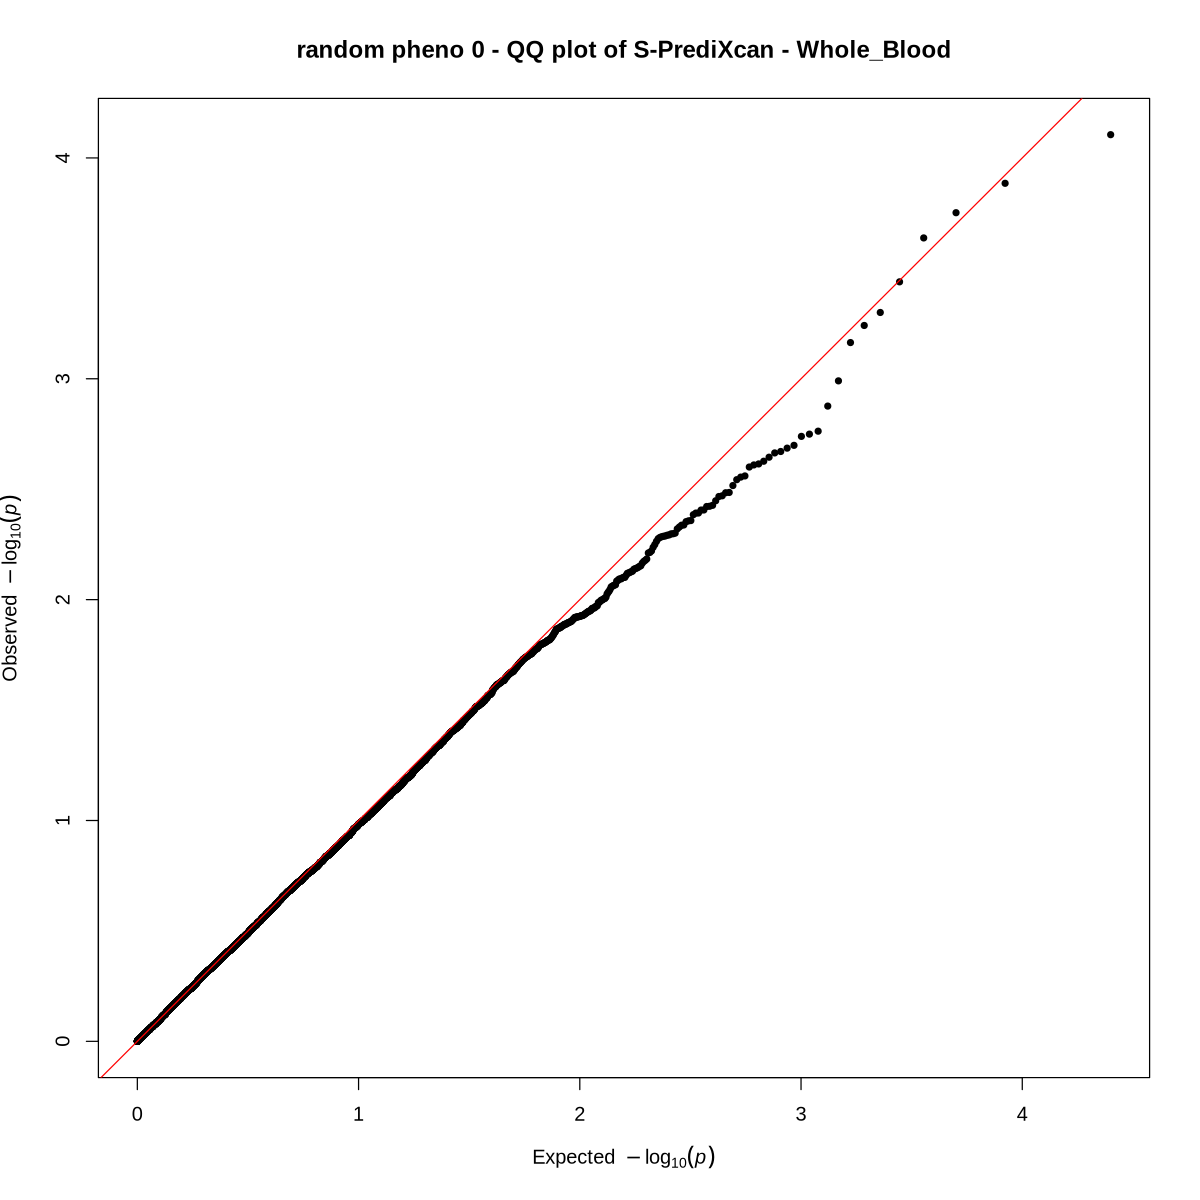

In [14]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-PrediXcan - ", tissue)
)

## S-MultiXcan

### Load data

In [15]:
twas <- as.data.frame(read_table(file.path(SMULTIXCAN_DIR, paste0("random.pheno", pheno_code, "-gtex_v8-mashr-smultixcan.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  gene = col_character(),
  gene_name = col_character(),
  pvalue = col_double(),
  n = col_double(),
  n_indep = col_double(),
  p_i_best = col_double(),
  t_i_best = col_character(),
  p_i_worst = col_double(),
  t_i_worst = col_character(),
  eigen_max = col_double(),
  eigen_min = col_double(),
  eigen_min_kept = col_double(),
  z_min = col_double(),
  z_max = col_double(),
  z_mean = col_double(),
  z_sd = col_double(),
  tmi = col_double(),
  status = col_double()
)



In [16]:
dim(twas)

[1] 22519    18

In [17]:
head(twas)

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000254416.5,RP11-347E10.1,1.656101e-05,4,3,2.444542e-02,Spleen,0.2629156914,Nerve_Tibial,2.612788,1.693280e-02,0.3405801,-1.311768,2.250056,0.2619596,1.758121,3,0
2,ENSG00000271564.1,RP13-444H2.1,3.000779e-04,1,1,3.000779e-04,Testis,0.0003000779,Testis,1.000000,1.000000e+00,1.0000000,-3.615233,-3.615233,-3.6152327,NA,1,0
3,ENSG00000181788.3,SIAH2,4.668467e-04,45,1,4.222948e-05,Muscle_Skeletal,0.0172808571,Thyroid,43.177415,9.963391e-16,43.1774147,-4.094931,3.722543,-1.4779302,3.180245,1,0
4,ENSG00000168830.7,HTR1E,5.215506e-04,18,3,6.650053e-05,Thyroid,0.3840800165,Brain_Hippocampus,9.555565,7.385609e-18,1.1513981,-3.780852,3.988471,0.6381961,1.955544,3,0
5,ENSG00000148734.7,NPFFR1,6.180806e-04,22,6,5.663342e-03,Brain_Hippocampus,0.9735291173,Nerve_Tibial,11.780344,6.448113e-18,0.5202418,-2.766662,2.766662,-0.7094228,1.916941,6,0
6,ENSG00000036054.12,TBC1D23,6.317636e-04,43,3,4.073512e-03,Nerve_Tibial,0.9975946074,Adipose_Subcutaneous,30.779007,6.170009e-16,2.5097780,-2.872412,1.581920,-0.8240583,1.150355,3,0


### QQ-plot

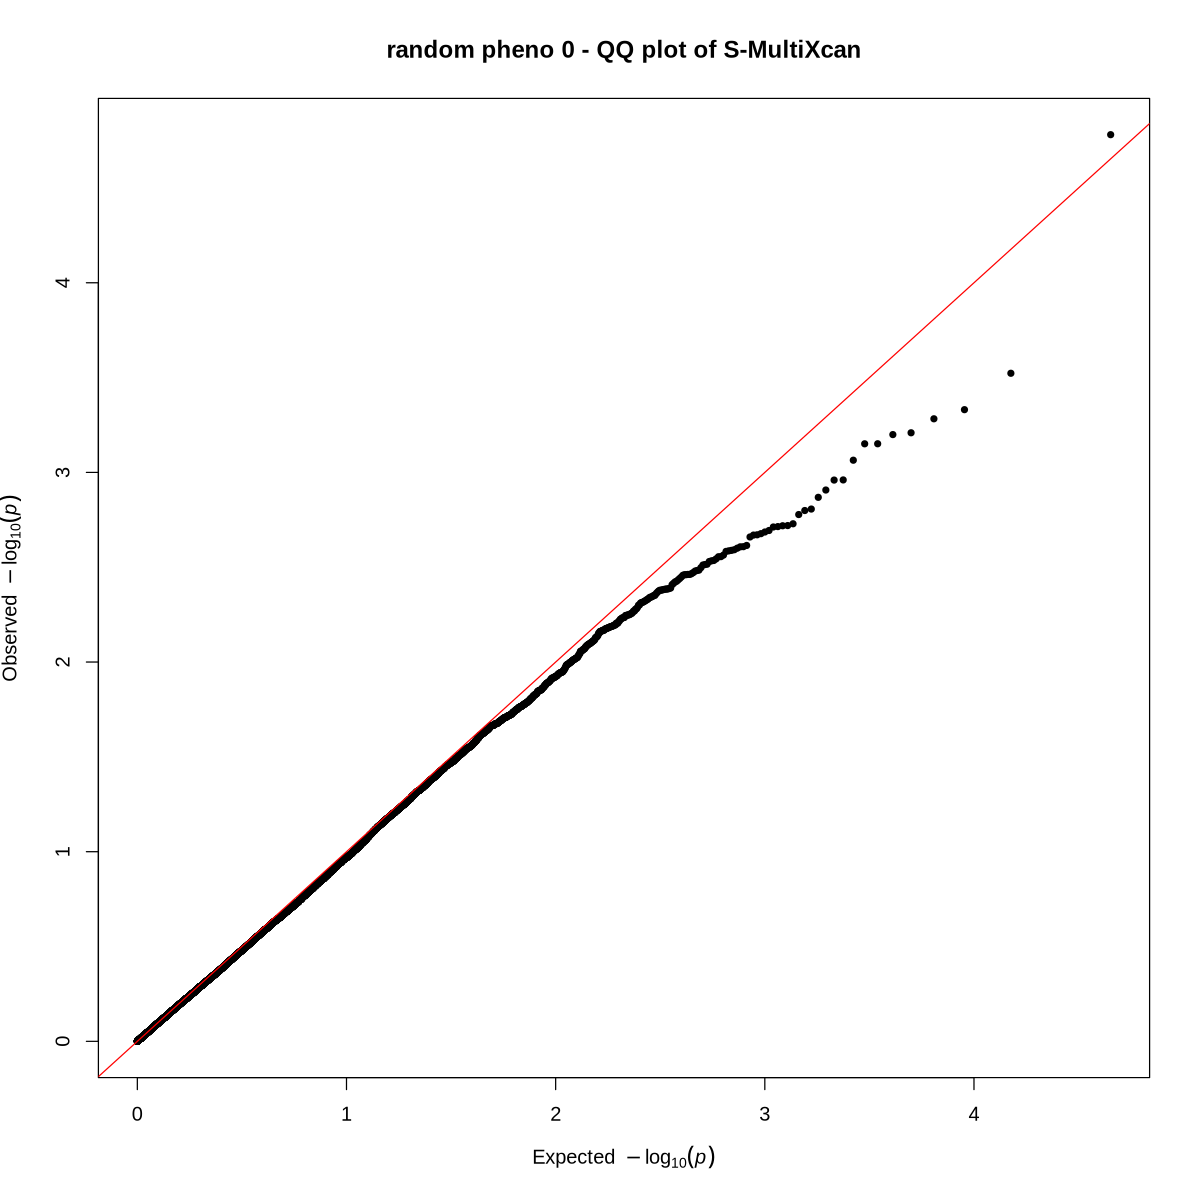

In [18]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-MultiXcan")
)

# Random pheno 1

In [19]:
pheno_code <- "1"

## S-PrediXcan

In [20]:
tissue <- "Whole_Blood"

### Load data

In [21]:
twas <- as.data.frame(read_csv(file.path(SPREDIXCAN_DIR, paste0("random.pheno", pheno_code,"-gtex_v8-mashr-", tissue,".csv"))))

Rows: 12594 Columns: 14
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): gene, gene_name
dbl (8): zscore, pvalue, var_g, n_snps_used, n_snps_in_cov, n_snps_in_model,...
lgl (4): effect_size, pred_perf_r2, pred_perf_pval, pred_perf_qval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [22]:
dim(twas)

[1] 12594    14

In [23]:
head(twas)

,gene,gene_name,zscore,effect_size,pvalue,var_g,pred_perf_r2,pred_perf_pval,pred_perf_qval,n_snps_used,n_snps_in_cov,n_snps_in_model,best_gwas_p,largest_weight
,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000132640.14,BTBD3,4.278332,NA,1.882991e-05,2.019144e-02,NA,NA,NA,2,2,2,3.112921e-05,0.199786132
2,ENSG00000106524.8,ANKMY2,4.024673,NA,5.705466e-05,7.823264e-03,NA,NA,NA,1,1,1,5.705466e-05,0.162169357
3,ENSG00000100226.15,GTPBP1,3.725404,NA,1.950030e-04,7.929574e-06,NA,NA,NA,1,1,1,1.950030e-04,0.009725399
4,ENSG00000158113.12,LRRC43,3.664281,NA,2.480339e-04,4.404839e-02,NA,NA,NA,2,2,2,8.400749e-05,0.216323401
5,ENSG00000219481.10,NBPF1,-3.651365,NA,2.608502e-04,8.133495e-02,NA,NA,NA,4,4,4,4.223471e-04,0.414501235
6,ENSG00000106701.11,FSD1L,-3.568818,NA,3.585956e-04,5.699194e-03,NA,NA,NA,1,1,1,3.585956e-04,0.111609617


### QQ-plot

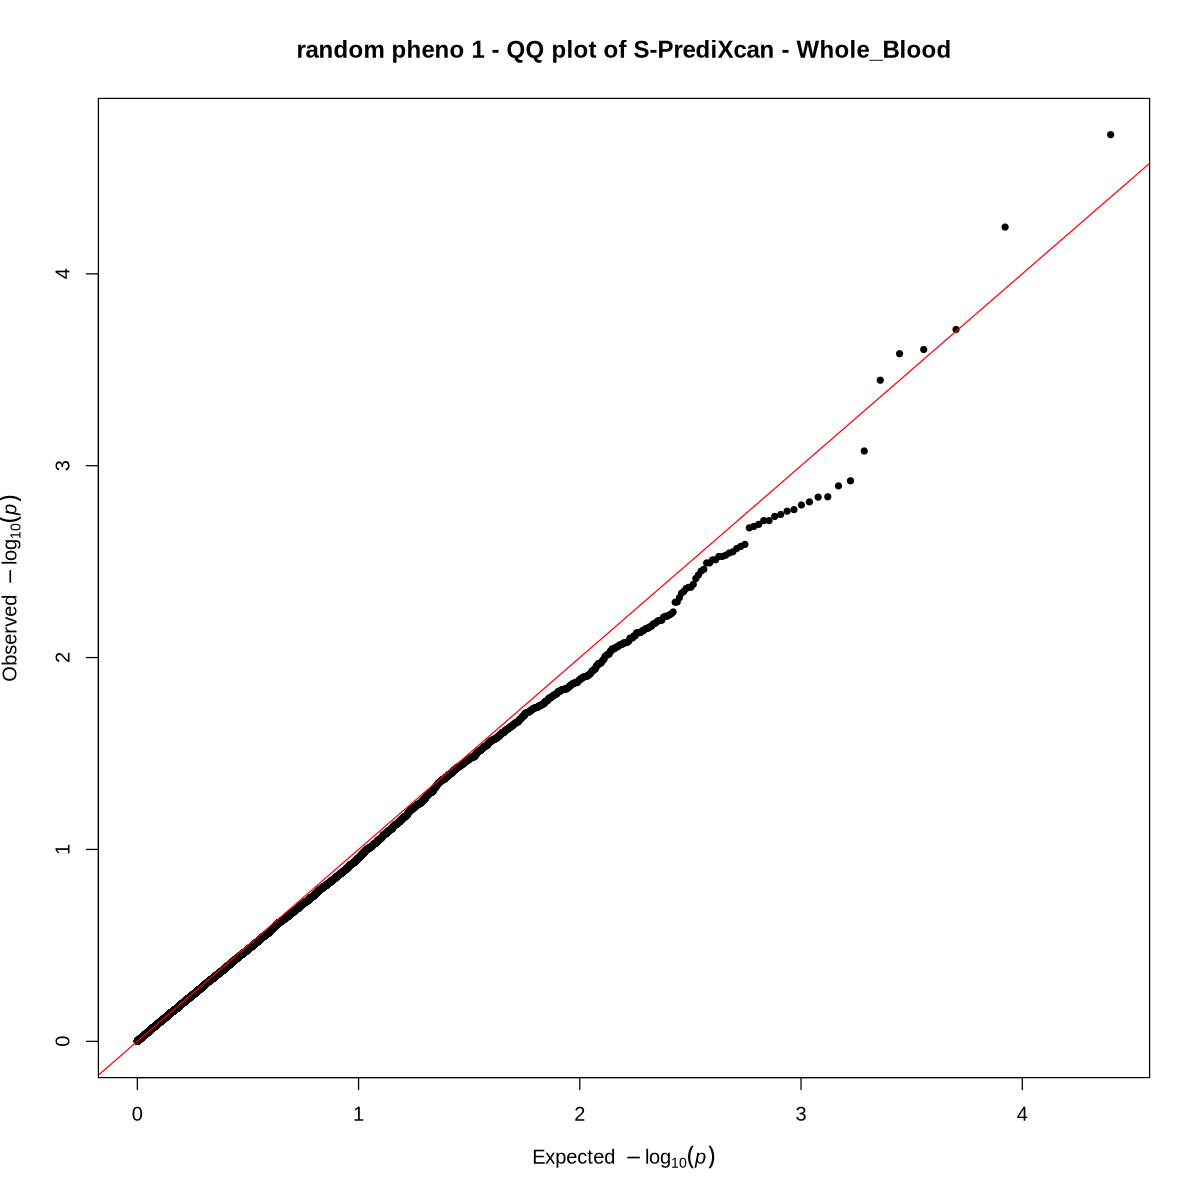

In [24]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-PrediXcan - ", tissue)
)

## S-MultiXcan

### Load data

In [25]:
twas <- as.data.frame(read_table(file.path(SMULTIXCAN_DIR, paste0("random.pheno", pheno_code, "-gtex_v8-mashr-smultixcan.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  gene = col_character(),
  gene_name = col_character(),
  pvalue = col_double(),
  n = col_double(),
  n_indep = col_double(),
  p_i_best = col_double(),
  t_i_best = col_character(),
  p_i_worst = col_double(),
  t_i_worst = col_character(),
  eigen_max = col_double(),
  eigen_min = col_double(),
  eigen_min_kept = col_double(),
  z_min = col_double(),
  z_max = col_double(),
  z_mean = col_double(),
  z_sd = col_double(),
  tmi = col_double(),
  status = col_double()
)



In [26]:
dim(twas)

[1] 22519    18

In [27]:
head(twas)

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000004399.12,PLXND1,6.289725e-05,29,6,1.541216e-04,Nerve_Tibial,0.9139688,Minor_Salivary_Gland,16.74650,3.818086e-16,0.9006081,-3.092967,3.784333,0.92962482,1.869188,6,0
2,ENSG00000158113.12,LRRC43,2.611654e-04,42,4,8.400749e-05,Brain_Frontal_Cortex_BA9,0.9573408,Brain_Cerebellum,27.50213,2.700013e-15,1.1429963,-3.932670,3.664281,0.02674259,1.571166,4,0
3,ENSG00000144057.15,ST6GAL2,2.737905e-04,34,9,2.168556e-05,Lung,0.6481448,Testis,13.06778,2.682641e-16,0.6480592,-4.246789,4.136065,0.11491716,2.689799,9,0
4,ENSG00000105427.9,CNFN,4.345944e-04,49,2,8.041927e-05,Vagina,0.9966530,Artery_Tibial,40.12629,7.167415e-16,8.4930273,-3.943147,3.873578,-1.19167954,1.564393,2,0
5,ENSG00000176884.14,GRIN1,4.604414e-04,29,3,2.041417e-05,Minor_Salivary_Gland,0.7272884,Brain_Putamen_basal_ganglia,24.10839,1.404268e-15,0.9671536,-4.260312,4.110487,-0.44340717,1.854890,3,0
6,ENSG00000164327.12,RICTOR,4.912627e-04,27,5,1.398946e-05,Prostate,0.7328532,Spleen,15.09544,8.504961e-16,0.7688933,-4.344027,1.237471,-0.25060461,1.131242,5,0


### QQ-plot

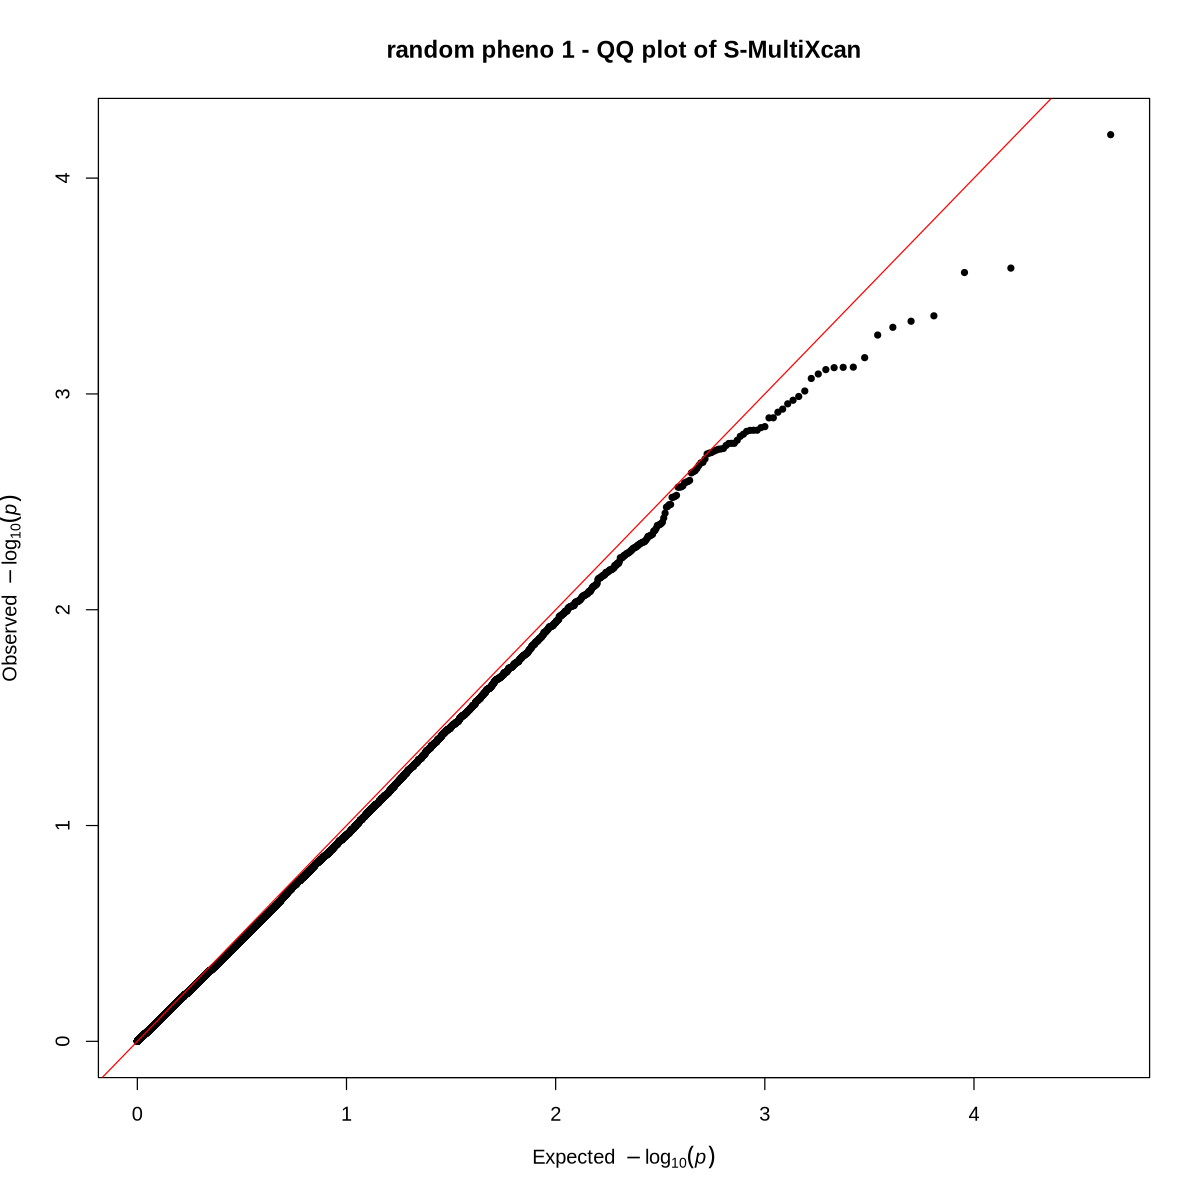

In [28]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-MultiXcan")
)

# Random pheno 2

In [29]:
pheno_code <- "2"

## S-PrediXcan

In [30]:
tissue <- "Whole_Blood"

### Load data

In [31]:
twas <- as.data.frame(read_csv(file.path(SPREDIXCAN_DIR, paste0("random.pheno", pheno_code,"-gtex_v8-mashr-", tissue,".csv"))))

Rows: 12594 Columns: 14
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): gene, gene_name
dbl (8): zscore, pvalue, var_g, n_snps_used, n_snps_in_cov, n_snps_in_model,...
lgl (4): effect_size, pred_perf_r2, pred_perf_pval, pred_perf_qval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [32]:
dim(twas)

[1] 12594    14

In [33]:
head(twas)

,gene,gene_name,zscore,effect_size,pvalue,var_g,pred_perf_r2,pred_perf_pval,pred_perf_qval,n_snps_used,n_snps_in_cov,n_snps_in_model,best_gwas_p,largest_weight
,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000157322.17,CLEC18A,-3.853969,NA,0.0001162184,5.230706e-01,NA,NA,NA,2,2,2,0.0004702915,0.6741594561
2,ENSG00000104915.14,STX10,3.691799,NA,0.0002226736,1.025868e-03,NA,NA,NA,2,2,2,0.0007954568,0.1269668684
3,ENSG00000182586.8,LINC00334,-3.631413,NA,0.0002818742,2.157466e-03,NA,NA,NA,1,1,1,0.0002818742,0.0737239128
4,ENSG00000157895.11,C12orf43,-3.558105,NA,0.0003735395,4.427575e-02,NA,NA,NA,3,3,3,0.0015707374,0.4190122426
5,ENSG00000267467.3,APOC4,-3.533980,NA,0.0004093518,2.621262e-12,NA,NA,NA,1,1,1,0.0004093518,0.0000096926
6,ENSG00000176971.3,FIBIN,-3.485510,NA,0.0004911997,2.116173e-05,NA,NA,NA,1,1,1,0.0004911997,0.0146245876


### QQ-plot

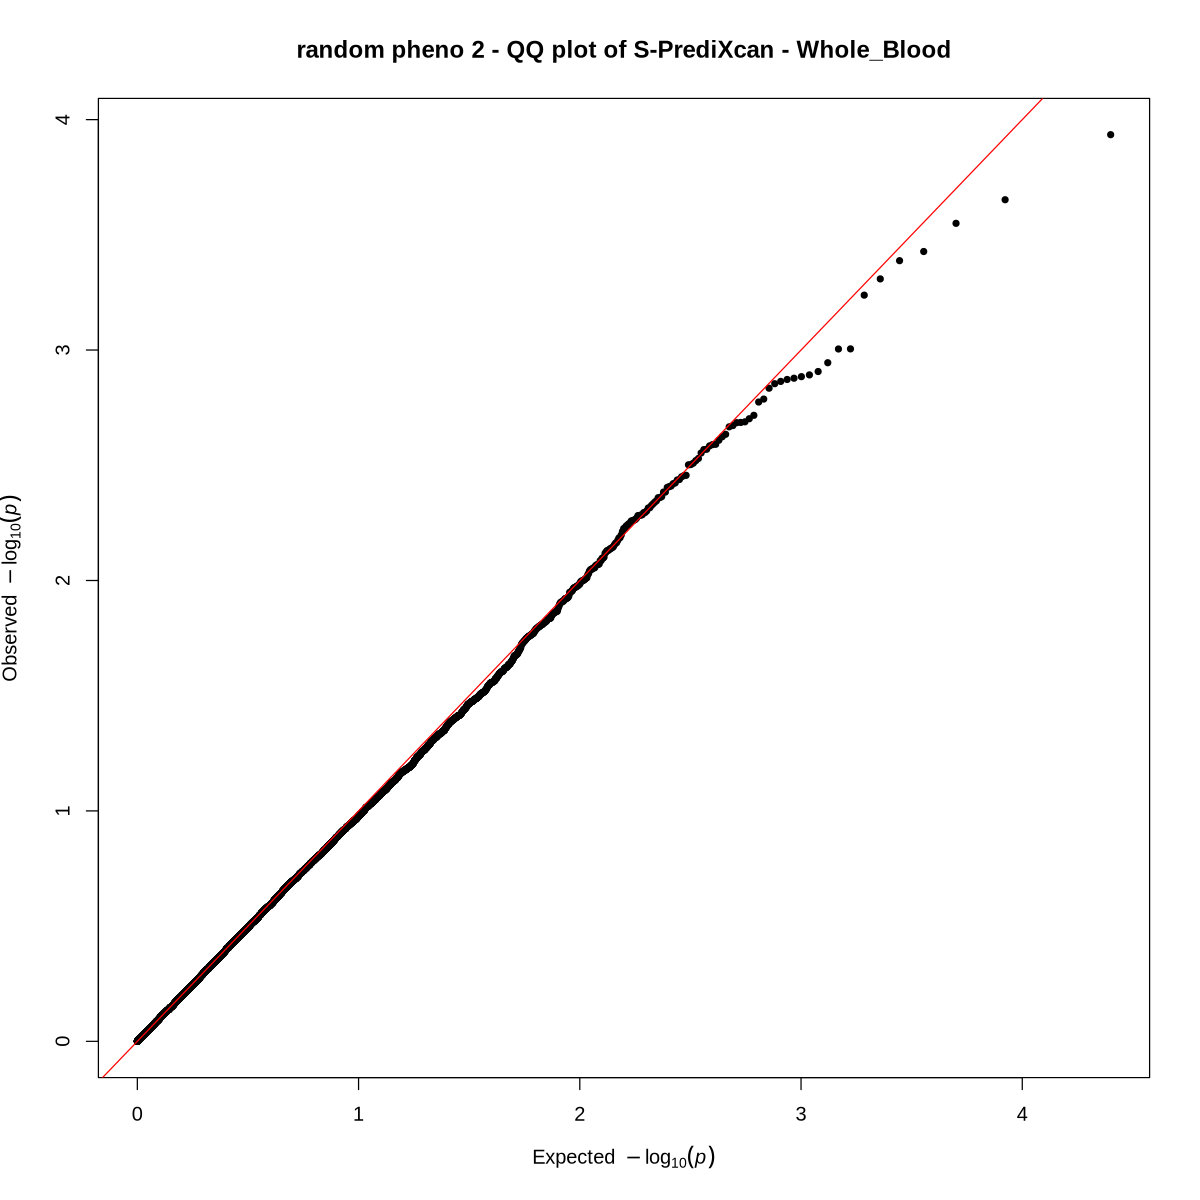

In [34]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-PrediXcan - ", tissue)
)

## S-MultiXcan

### Load data

In [35]:
twas <- as.data.frame(read_table(file.path(SMULTIXCAN_DIR, paste0("random.pheno", pheno_code, "-gtex_v8-mashr-smultixcan.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  gene = col_character(),
  gene_name = col_character(),
  pvalue = col_double(),
  n = col_double(),
  n_indep = col_double(),
  p_i_best = col_double(),
  t_i_best = col_character(),
  p_i_worst = col_double(),
  t_i_worst = col_character(),
  eigen_max = col_double(),
  eigen_min = col_double(),
  eigen_min_kept = col_double(),
  z_min = col_double(),
  z_max = col_double(),
  z_mean = col_double(),
  z_sd = col_double(),
  tmi = col_double(),
  status = col_double()
)



In [36]:
dim(twas)

[1] 22519    18

In [37]:
head(twas)

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000111276.10,CDKN1B,0.0001584752,36,5,2.508193e-03,Artery_Aorta,0.1645183,Brain_Cortex,16.721542,3.479898e-16,0.8743774,-3.022351,3.022351,0.2579828,2.144188,5,0
2,ENSG00000166689.15,PLEKHA7,0.0001793727,32,6,5.776996e-04,Whole_Blood,0.7930758,Thyroid,20.456530,1.885952e-15,0.8223887,-2.110599,3.441874,0.5403009,1.737683,6,0
3,ENSG00000179593.15,ALOX15B,0.0002292156,27,8,1.183886e-04,Colon_Sigmoid,0.6703208,Prostate,13.112486,9.145726e-16,0.6766076,-3.849439,3.706292,0.1941087,2.890992,8,0
4,ENSG00000233521.5,LINC01638,0.0002696232,17,7,2.694554e-03,Cells_Cultured_fibroblasts,0.7964130,Lung,9.089525,2.996577e-17,0.7709760,-1.609953,3.000592,0.4003949,1.779188,7,0
5,ENSG00000157335.20,CLEC18C,0.0003046432,26,6,3.115872e-05,Spleen,0.4271498,Brain_Cerebellar_Hemisphere,14.357152,1.351271e-15,0.6313380,-3.145844,4.164828,2.1291656,1.998366,6,0
6,ENSG00000157350.12,ST3GAL2,0.0003931901,27,3,5.110016e-03,Adipose_Visceral_Omentum,0.6002853,Skin_Sun_Exposed_Lower_leg,24.307413,2.816170e-16,0.9591534,-2.800015,2.800015,-1.7316379,2.081012,3,0


### QQ-plot

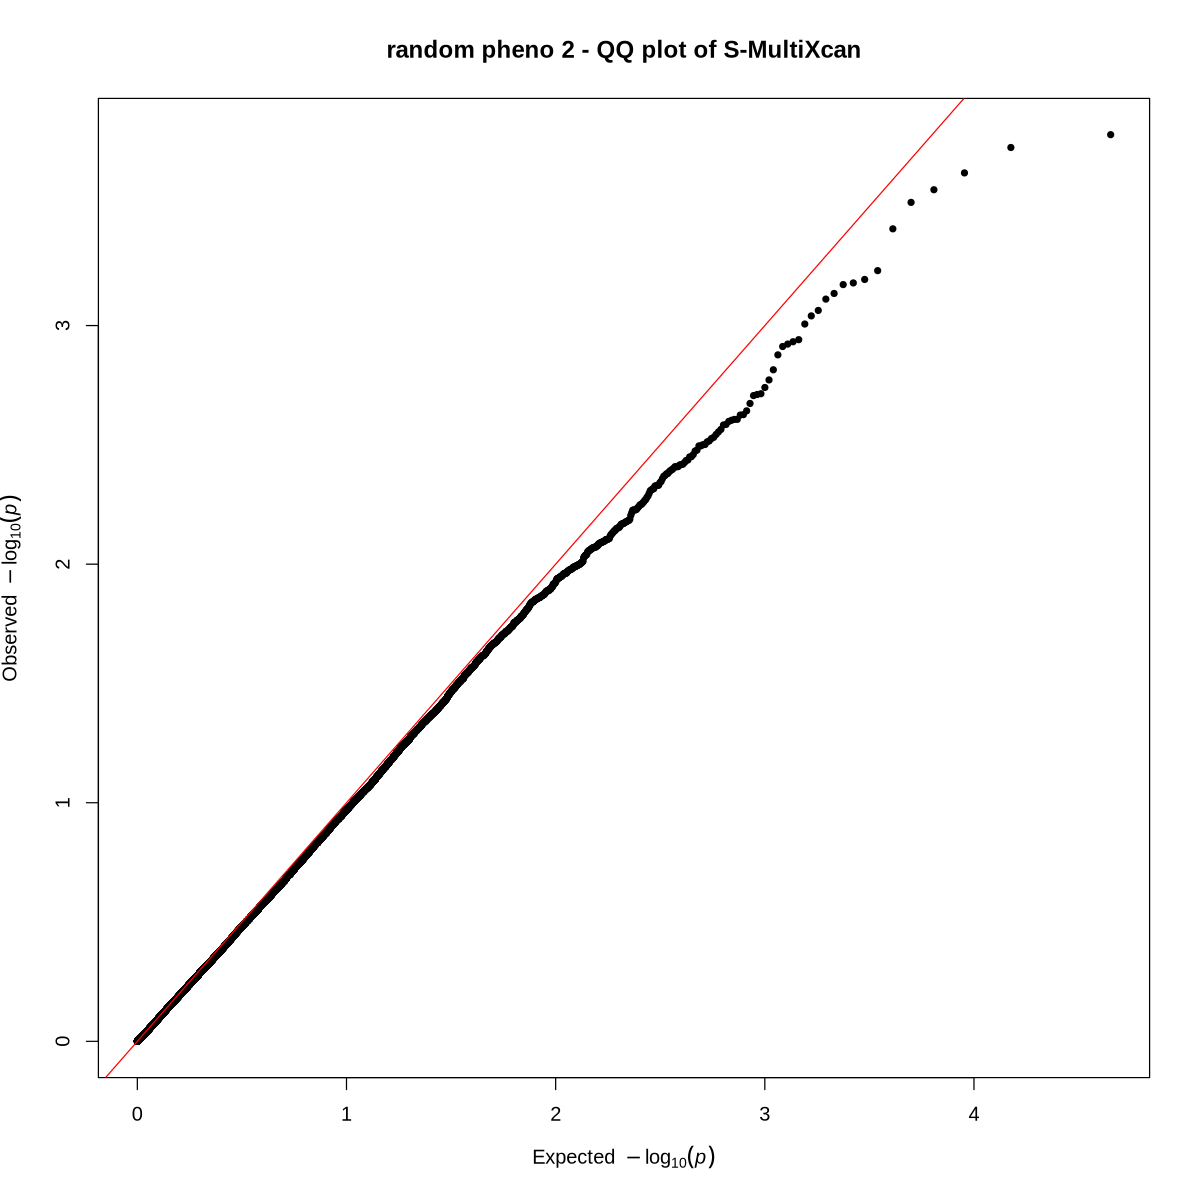

In [38]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-MultiXcan")
)

# Random pheno 3

In [39]:
pheno_code <- "3"

## S-PrediXcan

In [40]:
tissue <- "Whole_Blood"

### Load data

In [41]:
twas <- as.data.frame(read_csv(file.path(SPREDIXCAN_DIR, paste0("random.pheno", pheno_code,"-gtex_v8-mashr-", tissue,".csv"))))

Rows: 12594 Columns: 14
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): gene, gene_name
dbl (8): zscore, pvalue, var_g, n_snps_used, n_snps_in_cov, n_snps_in_model,...
lgl (4): effect_size, pred_perf_r2, pred_perf_pval, pred_perf_qval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [42]:
dim(twas)

[1] 12594    14

In [43]:
head(twas)

,gene,gene_name,zscore,effect_size,pvalue,var_g,pred_perf_r2,pred_perf_pval,pred_perf_qval,n_snps_used,n_snps_in_cov,n_snps_in_model,best_gwas_p,largest_weight
,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000159640.15,ACE,-4.322384,NA,1.543526e-05,2.171507e-02,NA,NA,NA,2,2,2,2.102685e-05,0.110611432
2,ENSG00000182272.11,B4GALNT4,-3.429294,NA,6.051532e-04,5.135343e-02,NA,NA,NA,2,2,2,4.922613e-04,0.284576904
3,ENSG00000181826.9,RELL1,3.372055,NA,7.460966e-04,8.507524e-07,NA,NA,NA,1,1,1,7.460966e-04,0.005521876
4,ENSG00000075975.15,MKRN2,3.303413,NA,9.551572e-04,5.706932e-02,NA,NA,NA,3,3,3,2.020711e-03,0.372999310
5,ENSG00000197892.12,KIF13B,3.201283,NA,1.368171e-03,1.521324e-06,NA,NA,NA,1,1,1,1.368171e-03,0.004203121
6,ENSG00000101082.13,SLA2,3.097854,NA,1.949272e-03,3.838020e-05,NA,NA,NA,1,1,1,1.949272e-03,0.031805673


### QQ-plot

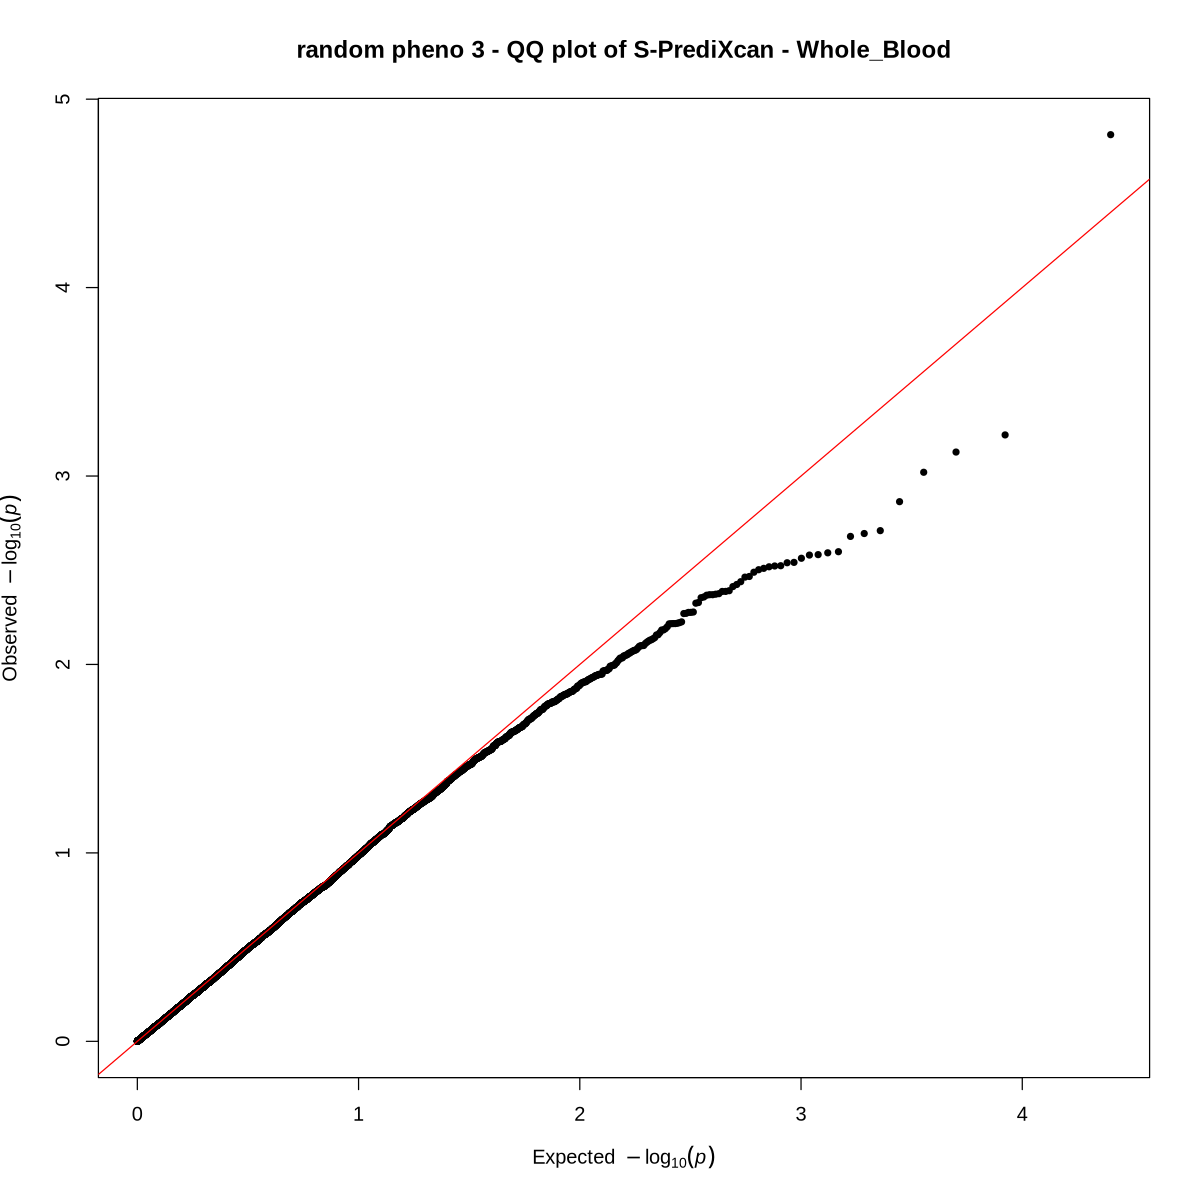

In [44]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-PrediXcan - ", tissue)
)

## S-MultiXcan

### Load data

In [45]:
twas <- as.data.frame(read_table(file.path(SMULTIXCAN_DIR, paste0("random.pheno", pheno_code, "-gtex_v8-mashr-smultixcan.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  gene = col_character(),
  gene_name = col_character(),
  pvalue = col_double(),
  n = col_double(),
  n_indep = col_double(),
  p_i_best = col_double(),
  t_i_best = col_character(),
  p_i_worst = col_double(),
  t_i_worst = col_character(),
  eigen_max = col_double(),
  eigen_min = col_double(),
  eigen_min_kept = col_double(),
  z_min = col_double(),
  z_max = col_double(),
  z_mean = col_double(),
  z_sd = col_double(),
  tmi = col_double(),
  status = col_double()
)



In [46]:
dim(twas)

[1] 22519    18

In [47]:
head(twas)

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000144026.11,ZNF514,0.0001370650,49,3,1.322239e-05,Brain_Cerebellar_Hemisphere,0.631489171,Kidney_Cortex,38.079559,3.746315e-15,2.2028017,-4.356392,0.4796319,-2.9353048,0.8573034,3,0
2,ENSG00000159640.15,ACE,0.0002157719,46,2,1.450868e-05,Nerve_Tibial,0.009289877,Muscle_Skeletal,42.738613,1.944214e-15,2.2105634,-4.336018,4.1007957,-2.1955699,3.3383045,2,0
3,ENSG00000130287.13,NCAN,0.0002547550,3,3,8.111134e-04,Brain_Putamen_basal_ganglia,0.092559285,Brain_Cerebellar_Hemisphere,1.393594,6.120236e-01,0.6120236,-3.348974,2.5305316,-0.8334973,3.0302108,3,0
4,ENSG00000174332.5,GLIS1,0.0004653016,42,2,5.507975e-05,Nerve_Tibial,0.859346804,Cells_Cultured_fibroblasts,36.873740,3.638567e-15,3.2698932,-4.032955,0.1772057,-3.5048546,0.7776641,2,0
5,ENSG00000177614.10,PGBD5,0.0006573773,46,6,6.723864e-04,Thyroid,0.989193775,Artery_Tibial,23.622371,1.614467e-15,1.0041449,-3.400598,3.2528812,0.1435638,1.1416564,6,0
6,ENSG00000120963.11,ZNF706,0.0007075155,39,6,1.021899e-04,Adrenal_Gland,0.623020605,Adipose_Visceral_Omentum,18.105308,1.450786e-15,0.9700299,-1.701080,3.8853325,-0.6694330,1.3139406,6,0


### QQ-plot

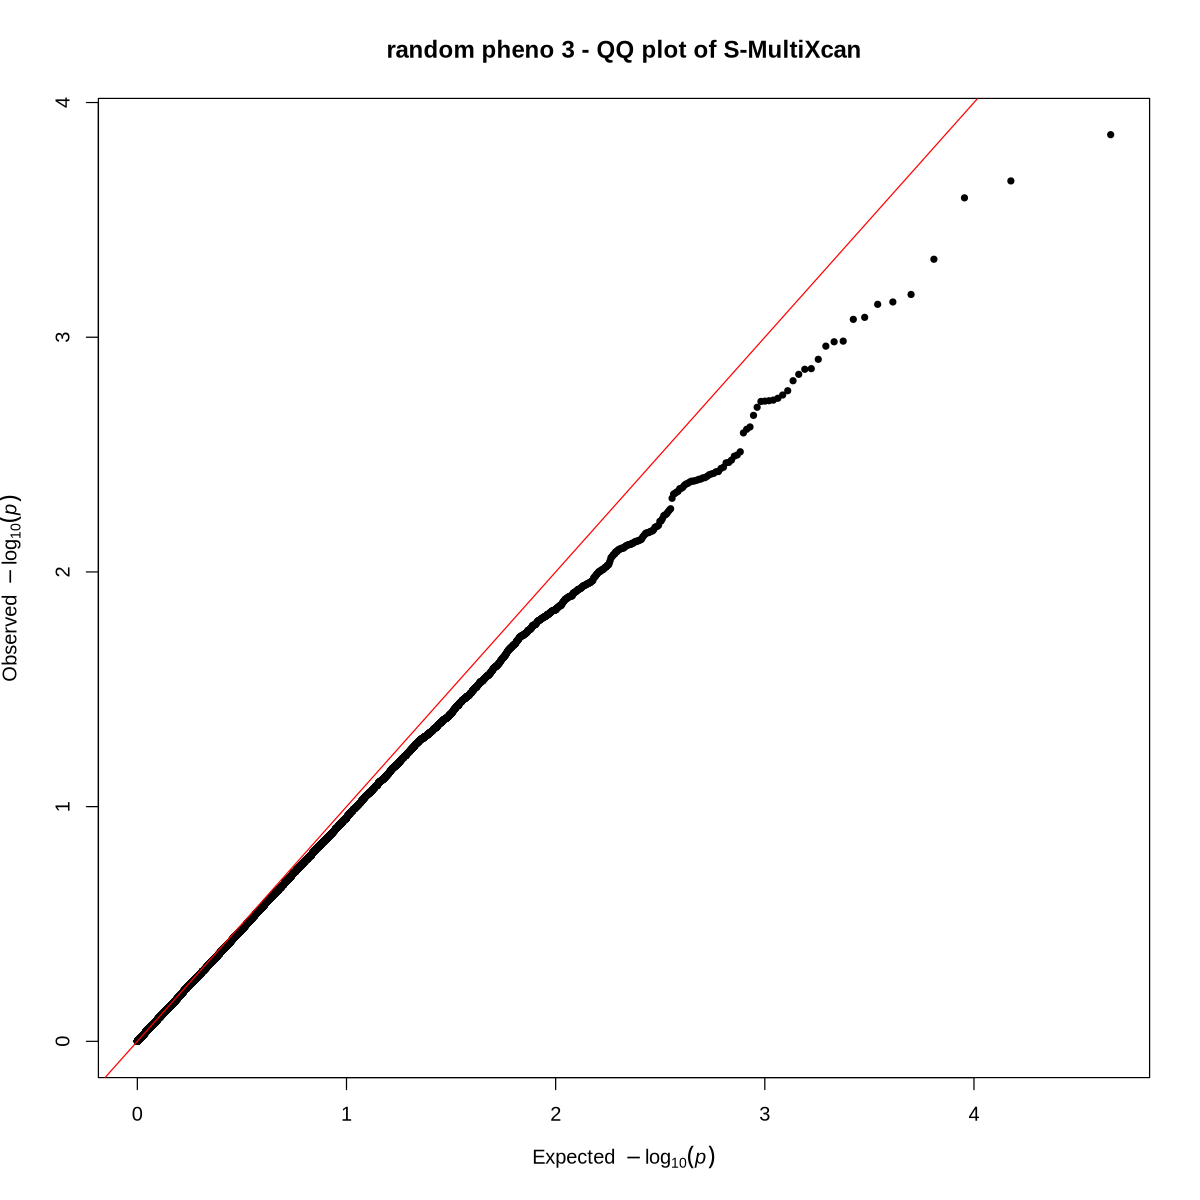

In [48]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-MultiXcan")
)

# Random pheno 4

In [49]:
pheno_code <- "4"

## S-PrediXcan

In [50]:
tissue <- "Whole_Blood"

### Load data

In [51]:
twas <- as.data.frame(read_csv(file.path(SPREDIXCAN_DIR, paste0("random.pheno", pheno_code,"-gtex_v8-mashr-", tissue,".csv"))))

Rows: 12594 Columns: 14
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): gene, gene_name
dbl (8): zscore, pvalue, var_g, n_snps_used, n_snps_in_cov, n_snps_in_model,...
lgl (4): effect_size, pred_perf_r2, pred_perf_pval, pred_perf_qval

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [52]:
dim(twas)

[1] 12594    14

In [53]:
head(twas)

,gene,gene_name,zscore,effect_size,pvalue,var_g,pred_perf_r2,pred_perf_pval,pred_perf_qval,n_snps_used,n_snps_in_cov,n_snps_in_model,best_gwas_p,largest_weight
,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000179240.9,RP11-111M22.2,3.633541,NA,0.0002795584,0.0013688539,NA,NA,NA,1,1,1,0.0002795584,0.15840232
2,ENSG00000182557.7,SPNS3,-3.501278,NA,0.0004630327,0.0002074516,NA,NA,NA,1,1,1,0.0004630327,0.02309122
3,ENSG00000143418.19,CERS2,3.484281,NA,0.0004934603,0.0015290888,NA,NA,NA,2,2,2,0.0006317911,0.09389891
4,ENSG00000170667.14,RASA4B,3.455595,NA,0.0005490804,0.0871867665,NA,NA,NA,4,4,4,0.0007123943,0.35999751
5,ENSG00000100664.10,EIF5,3.444764,NA,0.0005715584,0.0014216258,NA,NA,NA,1,1,1,0.0005715584,0.05847892
6,ENSG00000272156.1,RP11-477N3.1,3.351092,NA,0.0008049356,0.0205331681,NA,NA,NA,3,3,3,0.0180532863,0.31159342


### QQ-plot

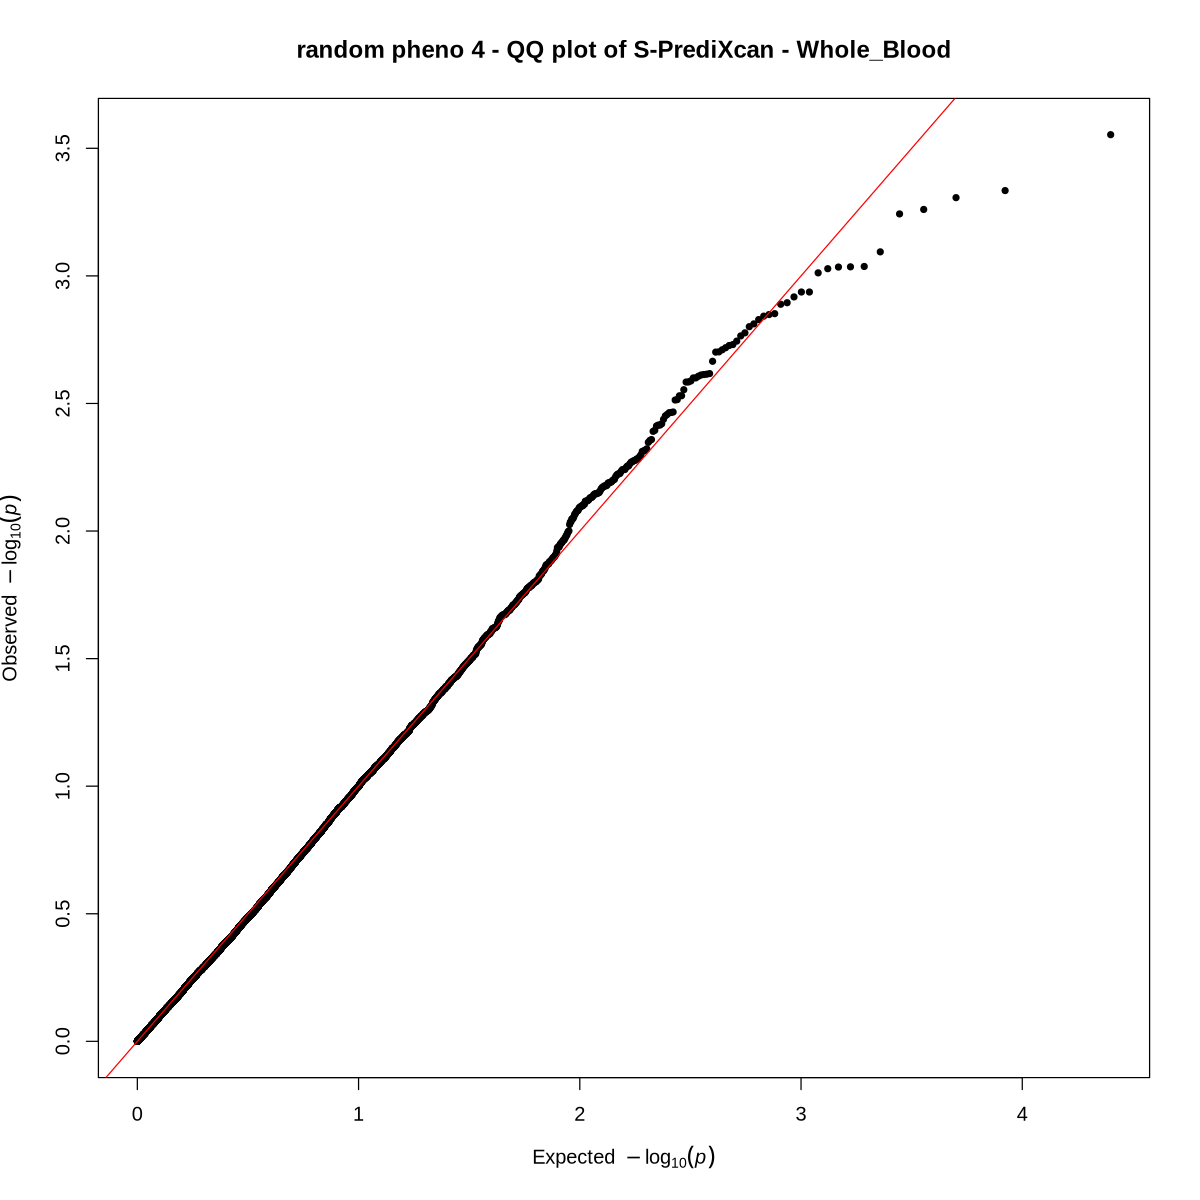

In [54]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-PrediXcan - ", tissue)
)

## S-MultiXcan

### Load data

In [55]:
twas <- as.data.frame(read_table(file.path(SMULTIXCAN_DIR, paste0("random.pheno", pheno_code, "-gtex_v8-mashr-smultixcan.txt"))))


── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
cols(
  gene = col_character(),
  gene_name = col_character(),
  pvalue = col_double(),
  n = col_double(),
  n_indep = col_double(),
  p_i_best = col_double(),
  t_i_best = col_character(),
  p_i_worst = col_double(),
  t_i_worst = col_character(),
  eigen_max = col_double(),
  eigen_min = col_double(),
  eigen_min_kept = col_double(),
  z_min = col_double(),
  z_max = col_double(),
  z_mean = col_double(),
  z_sd = col_double(),
  tmi = col_double(),
  status = col_double()
)



In [56]:
dim(twas)

[1] 22519    18

In [57]:
head(twas)

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000115561.15,CHMP3,0.0001173126,49,3,8.103688e-05,Brain_Cerebellar_Hemisphere,0.9191939827,Cells_EBV-transformed_lymphocytes,41.676186,1.114471e-15,2.8606027,-3.9413127,3.561598,1.0726006,1.3604055,3,0
2,ENSG00000239305.6,RNF103,0.0001319088,39,4,2.544511e-05,Brain_Hippocampus,0.8559675446,Brain_Amygdala,22.983558,5.308586e-16,0.9681034,-4.2108150,1.243871,-2.3796508,1.9988166,4,0
3,ENSG00000271945.1,RP11-354K4.2,0.0001329263,11,4,4.735465e-06,Brain_Hypothalamus,0.3375924182,Kidney_Cortex,7.687786,6.759777e-17,0.5209216,0.9589332,4.576179,2.1364889,0.9477891,4,0
4,ENSG00000259182.5,RP11-424I19.2,0.0001432885,18,5,7.562155e-04,Small_Intestine_Terminal_Ileum,0.9795158537,Artery_Aorta,12.201664,7.709436e-18,0.6596310,-3.3683426,1.741204,-1.3401780,1.2086482,5,0
5,ENSG00000280081.3,LINC01667,0.0001594751,1,1,1.594751e-04,Adipose_Visceral_Omentum,0.0001594751,Adipose_Visceral_Omentum,1.000000,1.000000e+00,1.0000000,-3.7758310,-3.775831,-3.7758310,NA,1,0
6,ENSG00000272156.1,RP11-477N3.1,0.0002978724,49,6,5.873135e-04,Testis,0.9969507410,Spleen,35.431801,3.483754e-15,1.3230935,-1.4279722,3.437406,0.6723624,1.0899986,6,0


### QQ-plot

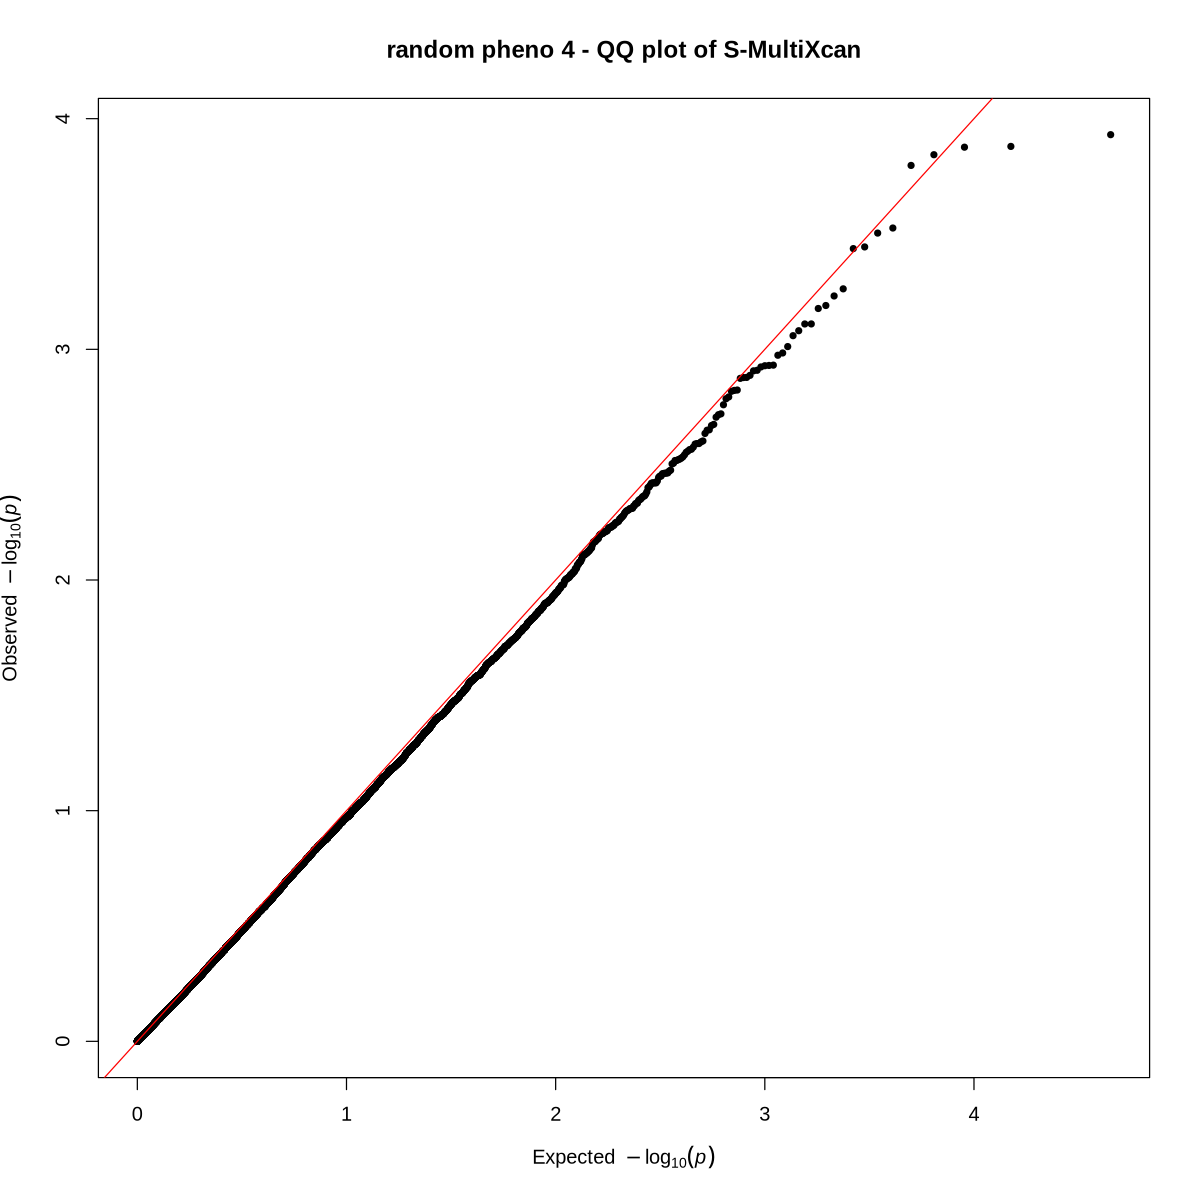

In [58]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq(
    twas$pvalue,
    main = paste0("random pheno ", pheno_code, " - QQ plot of S-MultiXcan")
)